Exploratory Data Analysis (EDA)

### 1. Load Dataset

In [ ]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = load_dataset("fancyzhx/yelp_polarity")

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})

### 2. Conversion into DataFrame

In [22]:
df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas()

print("Train:", df_train.shape)
print("Test :", df_test.shape)

Train: (560000, 2)
Test : (38000, 2)


### 3. First data overview

In [23]:
df_train.head()
df_train.sample(5, random_state=42)

,text,label
34566,This place is one of my favorite comic shops. ...,1
223092,The wait time for an appointment is ridiculous...,0
110270,I did not like this hotel at all. It's very ol...,0
365013,Mill Avenue has a serious issue with parking. ...,1
311625,Favorite sushi place in NV! Price is reasonab...,1


### 4. Dataset structure

In [24]:
df_train.info()
df_train.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 560000 entries, 0 to 559999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    560000 non-null  str  
 1   label   560000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 396.5 MB


,text,label
count,560000,560000.0
unique,560000,NaN
top,"Unfortunately, the frustration of being Dr. Go...",NaN
freq,1,NaN
mean,NaN,0.5
std,NaN,0.5
min,NaN,0.0
25%,NaN,0.0
50%,NaN,0.5
75%,NaN,1.0


### 5. Missing values

In [25]:
df_train.isnull().sum()
df_test.isnull().sum()

text     0
label    0
dtype: int64

### 6. Duplicates

In [26]:
print("Duplicate rows:", df_train.duplicated().sum())
print("Duplicate texts:", df_train["text"].duplicated().sum())

Duplicate rows: 0
Duplicate texts: 0


### 7. Class distribution

In [27]:
label_counts = df_train["label"].value_counts().sort_index()
label_counts

label_percentages = (
    df_train["label"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

label_percentages

label
0    50.0
1    50.0
Name: proportion, dtype: float64

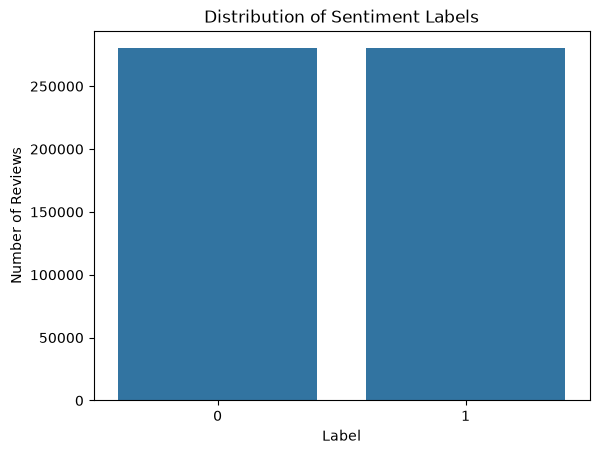

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df_train, x="label")

plt.title("Distribution of Sentiment Labels")
plt.xlabel("Label")
plt.ylabel("Number of Reviews")
plt.show()

### 8. What 0 e 1 mean

In [29]:
print("LABEL 0")
print("=" * 80)

for text in df_train[df_train["label"] == 0]["text"].head(3):
    print(text)
    print("-" * 80)

print("LABEL 1")
print("=" * 80)

for text in df_train[df_train["label"] == 1]["text"].head(3):
    print(text)
    print("-" * 80)  

LABEL 0
Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.
--------------------------------------------------------------------------------
I don't know what Dr. Goldberg was like before  moving to Arizona, but let me tell you, STAY AWAY from this doctor and this office. I was going to Dr. Johnson before he left and Goldberg took over when Johnson left. He is not a caring doctor. He is only interested in

### 9. Lenght of the reviews

(this info will be useful when we will work with DistilBERT due to the transformers work with limited length of the sequence)

In [30]:
df_train["text_length"] = df_train["text"].str.len()
df_train["text_length"].describe()

count    560000.000000
mean        726.497923
std         669.844273
min           1.000000
25%         279.000000
50%         528.000000
75%         947.000000
max        5273.000000
Name: text_length, dtype: float64

### 10. Review length distribution

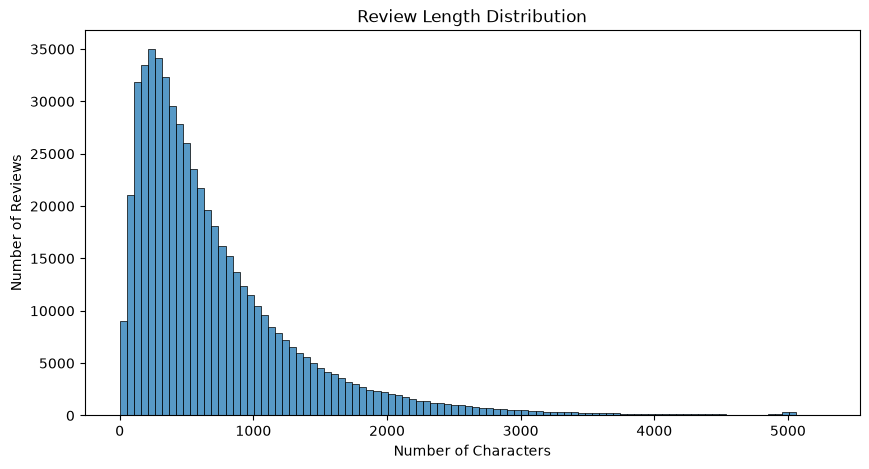

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_train,
    x="text_length",
    bins=100
)

plt.title("Review Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")

plt.show()

### 11. Review length by sentiment

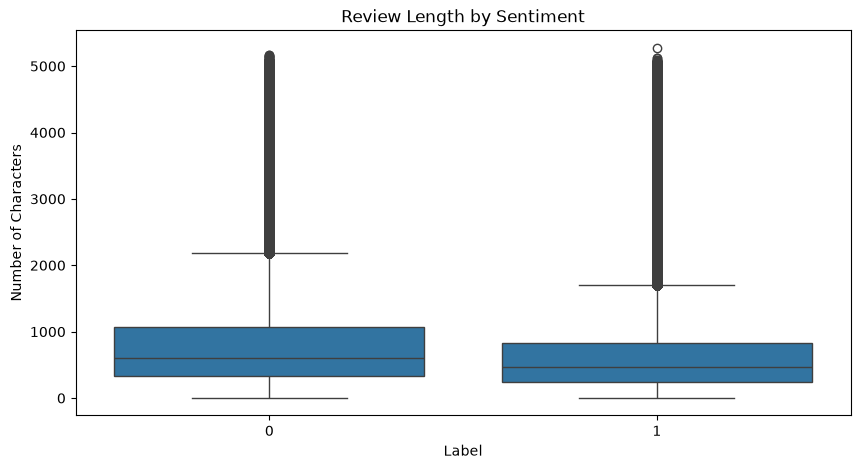

In [32]:
plt.figure(figsize=(10, 5))

sns.boxplot(            #o diagramma a scatola e baffi
    data=df_train,
    x="label",
    y="text_length"
)

plt.title("Review Length by Sentiment")
plt.xlabel("Label")
plt.ylabel("Number of Characters")

plt.show()

### 12. Check on extremly short/long reviews

In [37]:
df_train.nsmallest(10, "text_length")[["text", "label", "text_length"]]

,text,label,text_length
840,A,0,1
3765,.,0,1
43495,C,0,1
45573,K,1,1
54174,?,0,1
68944,X,0,1
72305,E,0,1
82363,Q,0,1
119681,x,0,1
291536,0,0,1


In [36]:
df_train.nlargest(10, "text_length")[["text", "label", "text_length"]]

,text,label,text_length
288294,Francais plus bas.\n\nHey why write a Costco r...,1,5273
426341,This review is for the UA reps at McCarran who...,0,5162
411885,Mellow Mushroom isn't exactly the sort of plac...,0,5160
135057,I'm going to tell you the end of this restaura...,0,5157
250957,"Oh, T.I. You should be ASHAMED to even call t...",0,5150
146324,"WORST hotel experience of my LIFE !! \""""Why\""...",0,5142
216248,Do you ever think that you're on Punk'D? Or on...,0,5132
107317,Ferraro's Italian Restaurant & Wine Bar is a u...,1,5129
354545,Yes 5 stars! Julian Serrano is worthy of all ...,1,5118
507840,Fast forward due to yelps word limit. \n\nThe ...,0,5116


### 13. Very important: train vs test

In [38]:
print("TRAIN")
print(df_train["label"].value_counts(normalize=True))

print("\nTEST")
print(df_test["label"].value_counts(normalize=True))

TRAIN
label
0    0.5
1    0.5
Name: proportion, dtype: float64

TEST
label
1    0.5
0    0.5
Name: proportion, dtype: float64


WHAT WE FOUND

Check               Result              Interpretation
Train               560,000             Dataset is fairly large
Columns             text, label         Simple structure suitable for classification
Missing values      0                   No handling required
Duplicate rows      0                   No complete duplicates
Duplicate texts     0                   No duplicate texts
Label 0             50%                 Balanced class
Label 1             50%                 Balanced class
Average length      ~726 characters     Fairly substantial reviews
Median              528 characters      The average is influenced by long reviews
Max                 5,273 characters    Some outliers present

CONCLUSION

The dataset contains 560,000 training examples and two balanced sentiment classes. No missing values or duplicate texts were detected. 0 Review length 0 are meanly longer than 1 review length. No invalid observations requiring removal were identified.

In [40]:
df_train.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,280000.0,820.862314,735.512805,1.0,325.0,604.0,1069.0,5162.0
1,280000.0,632.133532,581.889917,1.0,243.0,461.0,827.0,5273.0


### Text Length Analysis

Review length differs between the two sentiment classes. Negative reviews
(label 0) are longer on average than positive reviews (label 1), with mean
lengths of approximately 821 and 632 characters respectively.

Both distributions are right-skewed, with the mean exceeding the median
and a small number of very long reviews.

No invalid observations were identified, so long reviews will not be removed at this stage.